# Sonic Universe — Spotify Listening History EDA

**A multi-year analysis of personal listening patterns (2017–2026)**

---

## Table of Contents
1. [Setup & Imports](#1)
2. [Data Loading](#2)
3. [Data Cleaning & Privacy](#3)
4. [Overview Statistics](#4)
5. [Temporal Patterns](#5)
6. [Top Artists & Tracks](#6)
7. [Listening Behaviour](#7)
8. [Sampling Strategy](#8)
9. [Feature Enrichment — SpotifyFeatures](#9)
10. [Audio Feature Analysis](#10)
11. [Final Output: Top Songs with Features](#11)

---
## 1. Setup & Imports <a id='1'></a>

In [14]:
import json
import warnings
import calendar
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# ── Plotting style ────────────────────────────────────────────────────
SPOTIFY_GREEN  = '#1DB954'
SPOTIFY_BLACK  = '#191414'
HIGHLIGHT      = '#FF6B6B'
ACCENT3        = '#4ECDC4'
PALETTE        = [SPOTIFY_GREEN, HIGHLIGHT, ACCENT3,
                  '#FFA07A', '#9B59B6', '#3498DB',
                  '#F1C40F', '#E74C3C', '#2ECC71', '#1ABC9C']

plt.rcParams.update({
    'figure.dpi'         : 130,
    'axes.spines.top'    : False,
    'axes.spines.right'  : False,
    'axes.titlesize'     : 14,
    'axes.titleweight'   : 'bold',
    'axes.labelsize'     : 11,
    'font.size'          : 10,
})
sns.set_style('whitegrid')
sns.set_palette(PALETTE)

# ── Paths ─────────────────────────────────────────────────────────────
BASE_DIR   = Path('..').resolve()
DATA_DIR   = BASE_DIR / 'data'
OUTPUT_DIR = DATA_DIR / 'processed'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Sampling parameter ────────────────────────────────────────────────
SAMPLE_PER_YEAR = 100   # top-N songs (by play count) to keep per year

print(f'Project root : {BASE_DIR}')
print(f'Data dir     : {DATA_DIR}')
print(f'Output dir   : {OUTPUT_DIR}')

Project root : /Users/adrianrodriguez/Library/CloudStorage/GoogleDrive-jadrian.rod323@gmail.com/My Drive/sonic_universe
Data dir     : /Users/adrianrodriguez/Library/CloudStorage/GoogleDrive-jadrian.rod323@gmail.com/My Drive/sonic_universe/data
Output dir   : /Users/adrianrodriguez/Library/CloudStorage/GoogleDrive-jadrian.rod323@gmail.com/My Drive/sonic_universe/data/processed


---
## 2. Data Loading <a id='2'></a>

All audio streaming-history JSON files are loaded and concatenated into a single DataFrame.

In [15]:
def load_streaming_history(data_dir: Path) -> pd.DataFrame:
    """Load and concatenate all Streaming_History_Audio_*.json files."""
    audio_files = sorted(data_dir.glob('Streaming_History_Audio_*.json'))
    if not audio_files:
        raise FileNotFoundError(f'No audio streaming history files found in {data_dir}')

    print(f'Found {len(audio_files)} audio streaming history files\n')
    frames = []
    for f in audio_files:
        with open(f, 'r', encoding='utf-8') as fh:
            data = json.load(fh)
        df = pd.DataFrame(data)
        df['_source_file'] = f.name
        frames.append(df)
        print(f'  {f.name:<55}  {len(df):>7,} records')

    combined = pd.concat(frames, ignore_index=True)
    print(f'\nTotal records loaded: {len(combined):,}')
    return combined


raw_df = load_streaming_history(DATA_DIR)
print(f'\nShape: {raw_df.shape}')
raw_df.head(3)

Found 23 audio streaming history files

  Streaming_History_Audio_2017-2018_2.json                  15,712 records
  Streaming_History_Audio_2017_0.json                       15,896 records
  Streaming_History_Audio_2017_1.json                       15,776 records
  Streaming_History_Audio_2018-2019_5.json                  15,730 records
  Streaming_History_Audio_2018_3.json                       15,824 records
  Streaming_History_Audio_2018_4.json                       15,744 records
  Streaming_History_Audio_2019-2020_8.json                  15,697 records
  Streaming_History_Audio_2019_6.json                       15,714 records
  Streaming_History_Audio_2019_7.json                       15,768 records
  Streaming_History_Audio_2020-2021_11.json                 15,967 records
  Streaming_History_Audio_2020_10.json                      15,874 records
  Streaming_History_Audio_2020_9.json                       15,805 records
  Streaming_History_Audio_2021-2022_14.json                 

,ts,platform,ms_played,conn_country,ip_addr,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,episode_name,episode_show_name,spotify_episode_uri,audiobook_title,audiobook_uri,audiobook_chapter_uri,audiobook_chapter_title,reason_start,reason_end,shuffle,skipped,offline,offline_timestamp,incognito_mode,_source_file
0,2017-12-09T04:42:18Z,"iOS 10.3.3 (iPhone8,2)",3861,US,192.31.105.208,Blitzkrieg Bop - 2016 Remaster,Ramones,Ramones,spotify:track:4KcH1ZRV2W1q7Flq0QqC76,None,None,None,None,None,None,None,fwdbtn,fwdbtn,True,False,False,NaN,False,Streaming_History_Audio_2017-2018_2.json
1,2017-12-09T04:42:24Z,"iOS 10.3.3 (iPhone8,2)",6314,US,192.31.105.208,I'm Gonna Be (500 Miles),The Proclaimers,Finest,spotify:track:66S14BkJDxgkYxLl5DCqOz,None,None,None,None,None,None,None,fwdbtn,fwdbtn,True,False,False,NaN,False,Streaming_History_Audio_2017-2018_2.json
2,2017-12-09T04:42:32Z,"iOS 10.3.3 (iPhone8,2)",8021,US,192.31.105.208,Bastards of Young - 2006 Remaster,The Replacements,Don't You Know Who I Think I Was?: The Best of...,spotify:track:2yKnUcWDrWUTGyYXVwH7pF,None,None,None,None,None,None,None,fwdbtn,fwdbtn,True,False,False,NaN,False,Streaming_History_Audio_2017-2018_2.json


In [16]:
# Column overview before any cleaning
print('Columns and null counts:')
null_summary = pd.DataFrame({
    'dtype'      : raw_df.dtypes,
    'non_null'   : raw_df.notna().sum(),
    'null_pct'   : (raw_df.isna().mean() * 100).round(2),
})
print(null_summary.to_string())

Columns and null counts:
                                     dtype  non_null  null_pct
ts                                  object    359973    0.0000
platform                            object    359973    0.0000
ms_played                            int64    359973    0.0000
conn_country                        object    359973    0.0000
ip_addr                             object    359973    0.0000
master_metadata_track_name          object    356749    0.9000
master_metadata_album_artist_name   object    356749    0.9000
master_metadata_album_album_name    object    356749    0.9000
spotify_track_uri                   object    356749    0.9000
episode_name                        object      3224   99.1000
episode_show_name                   object      3224   99.1000
spotify_episode_uri                 object      3224   99.1000
audiobook_title                     object         0  100.0000
audiobook_uri                       object         0  100.0000
audiobook_chapter_uri         

---
## 3. Data Cleaning & Privacy <a id='3'></a>

**PII removed:**
- `ip_addr` — exact IP addresses (direct identifier)
- `platform` — OS/version string (can be a quasi-identifier)

Non-music rows (podcasts, audiobooks) are filtered out. Columns are renamed for clarity and temporal features are engineered.

In [17]:
# ── Columns that contain PII ──────────────────────────────────────────
PII_COLS = ['ip_addr', 'platform']

# ── Episode / audiobook-specific columns (null for music tracks) ───────
NON_MUSIC_COLS = [
    'episode_name', 'episode_show_name', 'spotify_episode_uri',
    'audiobook_title', 'audiobook_uri',
    'audiobook_chapter_uri', 'audiobook_chapter_title',
]


def clean_and_anonymize(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # 1. Drop PII
    pii_found = [c for c in PII_COLS if c in df.columns]
    df.drop(columns=pii_found, inplace=True)
    print(f'PII columns dropped: {pii_found}')

    # 2. Keep music tracks only (master_metadata_track_name must be present)
    before = len(df)
    df = df[df['master_metadata_track_name'].notna()].copy()
    print(f'Rows removed (non-music): {before - len(df):,}  |  Music rows: {len(df):,}')

    # 3. Drop non-music-specific columns
    nm_found = [c for c in NON_MUSIC_COLS if c in df.columns]
    df.drop(columns=nm_found, inplace=True)

    # 4. Drop internal helper column
    df.drop(columns=['_source_file'], inplace=True, errors='ignore')

    # 5. Rename for readability
    df.rename(columns={
        'ts'                                   : 'timestamp',
        'ms_played'                            : 'ms_played',
        'conn_country'                         : 'country',
        'master_metadata_track_name'           : 'track_name',
        'master_metadata_album_artist_name'    : 'artist_name',
        'master_metadata_album_album_name'     : 'album_name',
        'spotify_track_uri'                    : 'track_uri',
        'reason_start'                         : 'reason_start',
        'reason_end'                           : 'reason_end',
    }, inplace=True)

    # 6. Parse timestamp (UTC)
    df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)

    # 7. Temporal feature engineering
    df['year']        = df['timestamp'].dt.year
    df['month']       = df['timestamp'].dt.month
    df['month_name']  = df['timestamp'].dt.strftime('%b')
    df['day_of_week'] = df['timestamp'].dt.day_name()
    df['hour']        = df['timestamp'].dt.hour
    df['date']        = df['timestamp'].dt.date
    df['year_month']  = df['timestamp'].dt.to_period('M')

    # 8. Derived metrics
    df['minutes_played'] = df['ms_played'] / 60_000
    df['was_skipped']    = df['ms_played'] < 30_000   # < 30 s → treated as skip

    # 9. Extract clean track_id from URI (spotify:track:<id>)
    df['track_id'] = df['track_uri'].str.split(':').str[-1]

    # 10. Sort chronologically
    df.sort_values('timestamp', inplace=True)
    df.reset_index(drop=True, inplace=True)

    return df


clean_df = clean_and_anonymize(raw_df)
print(f'\nCleaned shape: {clean_df.shape}')
clean_df.head(3)

PII columns dropped: ['ip_addr', 'platform']
Rows removed (non-music): 3,224  |  Music rows: 356,749

Cleaned shape: (356749, 24)


,timestamp,ms_played,country,track_name,artist_name,album_name,track_uri,reason_start,reason_end,shuffle,skipped,offline,offline_timestamp,incognito_mode,year,month,month_name,day_of_week,hour,date,year_month,minutes_played,was_skipped,track_id
0,2017-03-11 02:59:24+00:00,254693,US,Red Tide,The Growlers,Are You In Or Out?,spotify:track:5o7taLCeXkjmrmOd9YR9iS,clickrow,trackdone,False,False,False,NaN,False,2017,3,Mar,Saturday,2,2017-03-11,2017-03,4.2449,False,5o7taLCeXkjmrmOd9YR9iS
1,2017-03-11 02:59:32+00:00,6196,US,Red Tide Rising,Orange Goblin,A Eulogy for the Damned,spotify:track:66Msn8nRBJhfo56TpVRPjj,trackdone,remote,False,False,False,NaN,False,2017,3,Mar,Saturday,2,2017-03-11,2017-03,0.1033,True,66Msn8nRBJhfo56TpVRPjj
2,2017-03-11 02:59:45+00:00,10499,US,Red Tide Rising,Orange Goblin,A Eulogy for the Damned,spotify:track:66Msn8nRBJhfo56TpVRPjj,remote,backbtn,False,False,False,NaN,False,2017,3,Mar,Saturday,2,2017-03-11,2017-03,0.1750,True,66Msn8nRBJhfo56TpVRPjj


---
## 4. Overview Statistics <a id='4'></a>

In [18]:
# ── High-level summary ────────────────────────────────────────────────
total_plays   = len(clean_df)
total_hours   = clean_df['minutes_played'].sum() / 60
unique_tracks  = clean_df['track_id'].nunique()
unique_artists = clean_df['artist_name'].nunique()
date_range     = f"{clean_df['timestamp'].min().date()}  →  {clean_df['timestamp'].max().date()}"
skip_rate      = clean_df['was_skipped'].mean() * 100

summary = {
    'Total play events'     : f'{total_plays:,}',
    'Total listening time'  : f'{total_hours:,.0f} hours',
    'Unique tracks'         : f'{unique_tracks:,}',
    'Unique artists'        : f'{unique_artists:,}',
    'Date range'            : date_range,
    'Overall skip rate'     : f'{skip_rate:.1f}%',
}

print('=' * 50)
print('  DATASET OVERVIEW')
print('=' * 50)
for k, v in summary.items():
    print(f'  {k:<28} {v}')
print('=' * 50)

  DATASET OVERVIEW
  Total play events            356,749
  Total listening time         10,524 hours
  Unique tracks                47,974
  Unique artists               11,907
  Date range                   2017-03-11  →  2026-03-29
  Overall skip rate            43.2%


 year  plays  hours  unique_tracks  unique_artists  skip_rate
 2017  33786   1122           7004            2016    35.1000
 2018  46238   1776           8912            2466    29.6000
 2019  47604   1408           9258            2829    44.3000
 2020  47407   1315           8087            2549    48.0000
 2021  47237   1239           9081            2889    48.9000
 2022  45845   1200          11143            3804    48.4000
 2023  48311   1293          13334            4517    46.0000
 2024  25672    764           7018            2173    41.0000
 2025  12339    351           5001            1745    45.3000
 2026   2310     56           1165             527    53.9000


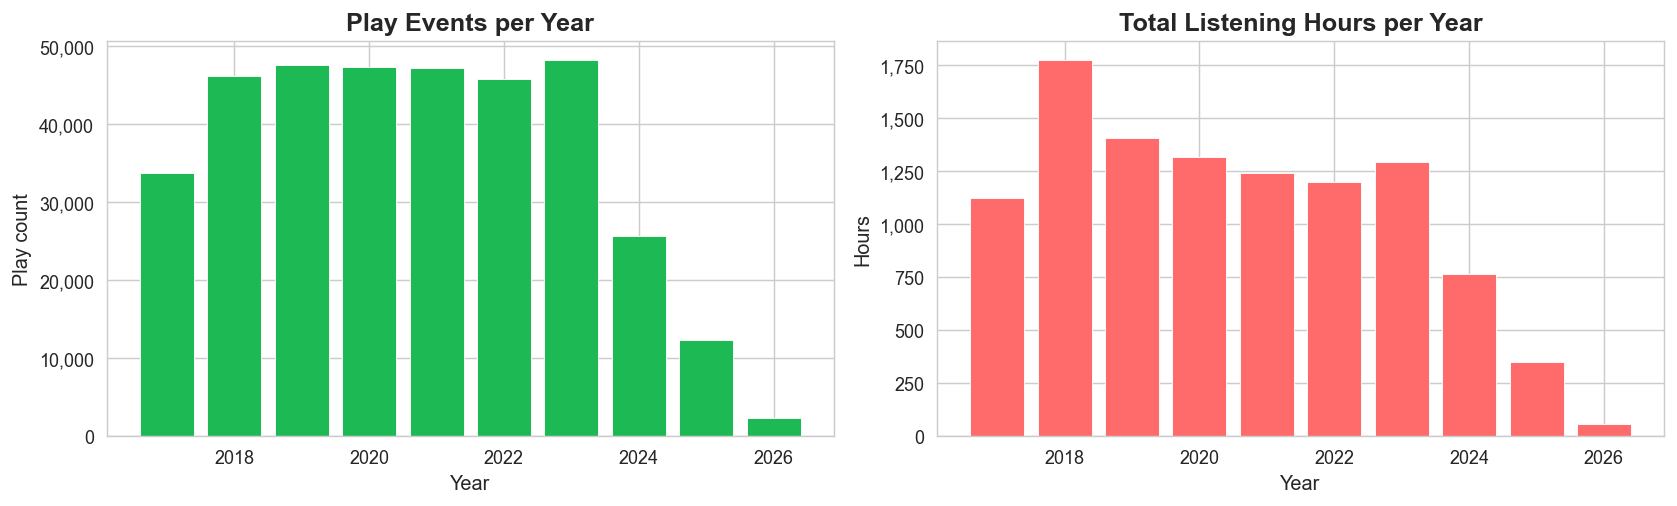

In [19]:
# ── Records per year ──────────────────────────────────────────────────
year_counts = (
    clean_df.groupby('year')
    .agg(plays=('track_id', 'count'),
         hours=('minutes_played', lambda x: x.sum() / 60),
         unique_tracks=('track_id', 'nunique'),
         unique_artists=('artist_name', 'nunique'),
         skip_rate=('was_skipped', 'mean'))
    .reset_index()
)
year_counts['skip_rate'] = (year_counts['skip_rate'] * 100).round(1)
year_counts['hours']     = year_counts['hours'].round(0).astype(int)
print(year_counts.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Plays per year
axes[0].bar(year_counts['year'], year_counts['plays'],
            color=SPOTIFY_GREEN, edgecolor='white', linewidth=0.5)
axes[0].set_title('Play Events per Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Play count')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Hours per year
axes[1].bar(year_counts['year'], year_counts['hours'],
            color=HIGHLIGHT, edgecolor='white', linewidth=0.5)
axes[1].set_title('Total Listening Hours per Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Hours')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_plays_per_year.png', bbox_inches='tight')
plt.show()

---
## 5. Temporal Patterns <a id='5'></a>

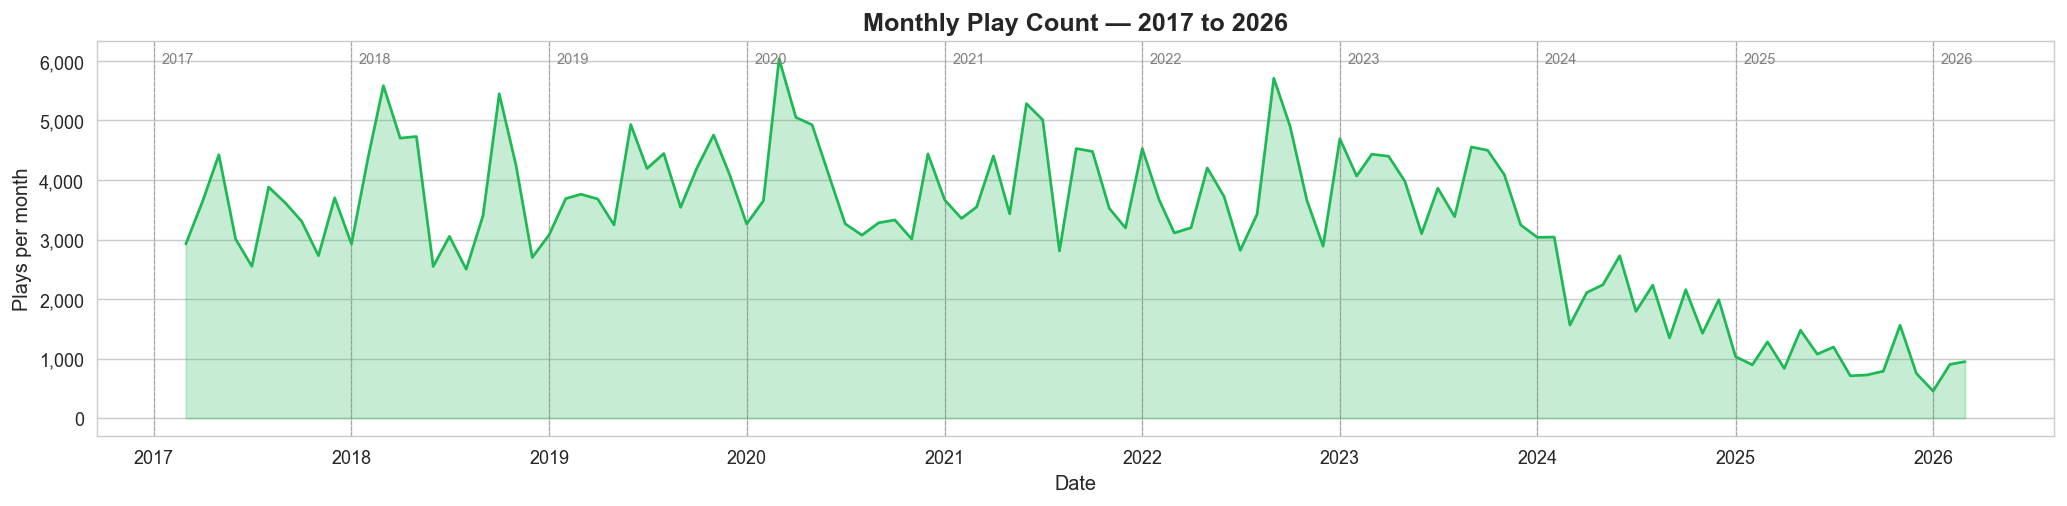

In [20]:
# ── Monthly listening trend (2017–2026) ───────────────────────────────
monthly = (
    clean_df.groupby('year_month')
    .agg(plays=('track_id', 'count'),
         hours=('minutes_played', lambda x: x.sum() / 60))
    .reset_index()
)
monthly['year_month_dt'] = monthly['year_month'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(16, 4))
ax.fill_between(monthly['year_month_dt'], monthly['plays'],
                color=SPOTIFY_GREEN, alpha=0.25)
ax.plot(monthly['year_month_dt'], monthly['plays'],
        color=SPOTIFY_GREEN, linewidth=1.5)
ax.set_title('Monthly Play Count — 2017 to 2026')
ax.set_xlabel('Date')
ax.set_ylabel('Plays per month')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
# Year markers
for yr in range(2017, 2027):
    ax.axvline(pd.Timestamp(f'{yr}-01-01'), color='grey',
               linewidth=0.6, linestyle='--', alpha=0.5)
    ax.text(pd.Timestamp(f'{yr}-01-15'), ax.get_ylim()[1] * 0.97,
            str(yr), fontsize=8, color='grey', va='top')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_monthly_trend.png', bbox_inches='tight')
plt.show()

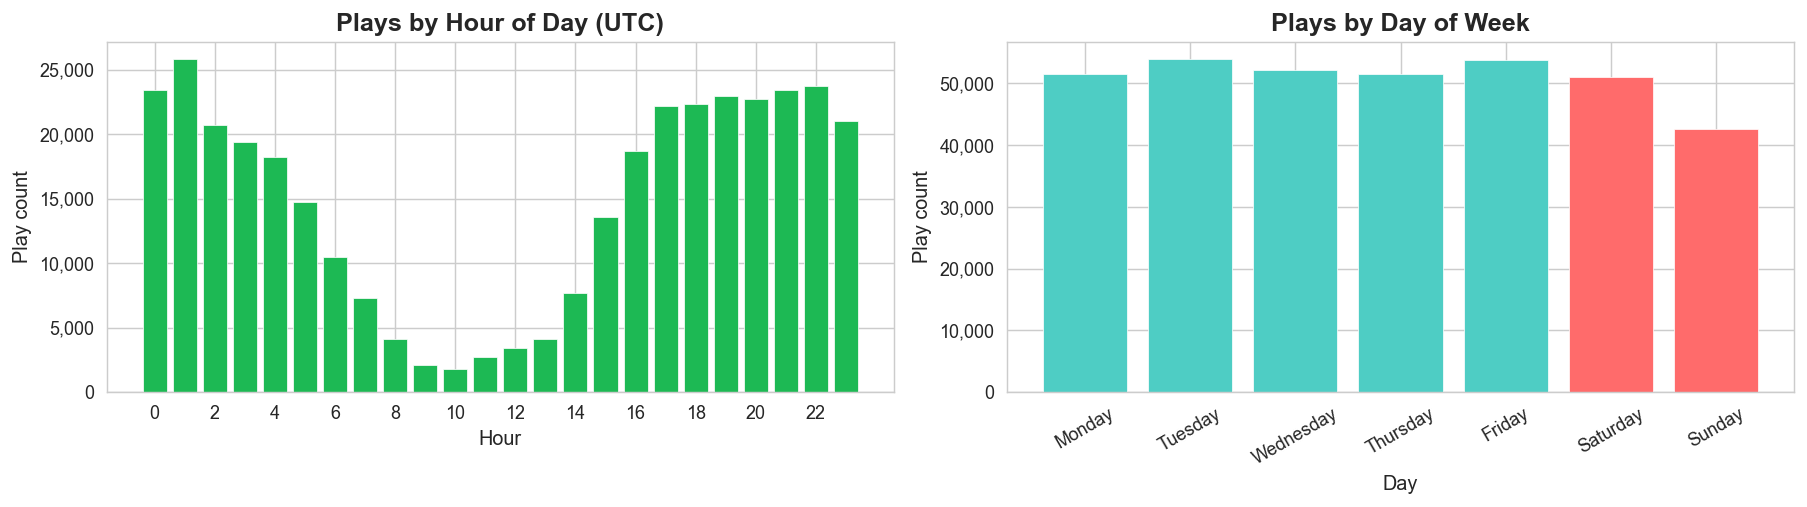

In [21]:
# ── Hourly & day-of-week patterns ─────────────────────────────────────
DOW_ORDER = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

hourly = clean_df.groupby('hour').size().reset_index(name='plays')
dow    = (
    clean_df.groupby('day_of_week').size()
    .reindex(DOW_ORDER)
    .reset_index(name='plays')
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Hour of day
axes[0].bar(hourly['hour'], hourly['plays'],
            color=SPOTIFY_GREEN, edgecolor='white', linewidth=0.4)
axes[0].set_title('Plays by Hour of Day (UTC)')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Play count')
axes[0].set_xticks(range(0, 24, 2))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Day of week
colors_dow = [HIGHLIGHT if d in ('Saturday', 'Sunday') else ACCENT3 for d in DOW_ORDER]
axes[1].bar(dow['day_of_week'], dow['plays'],
            color=colors_dow, edgecolor='white', linewidth=0.4)
axes[1].set_title('Plays by Day of Week')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Play count')
axes[1].tick_params(axis='x', rotation=30)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_temporal_patterns.png', bbox_inches='tight')
plt.show()

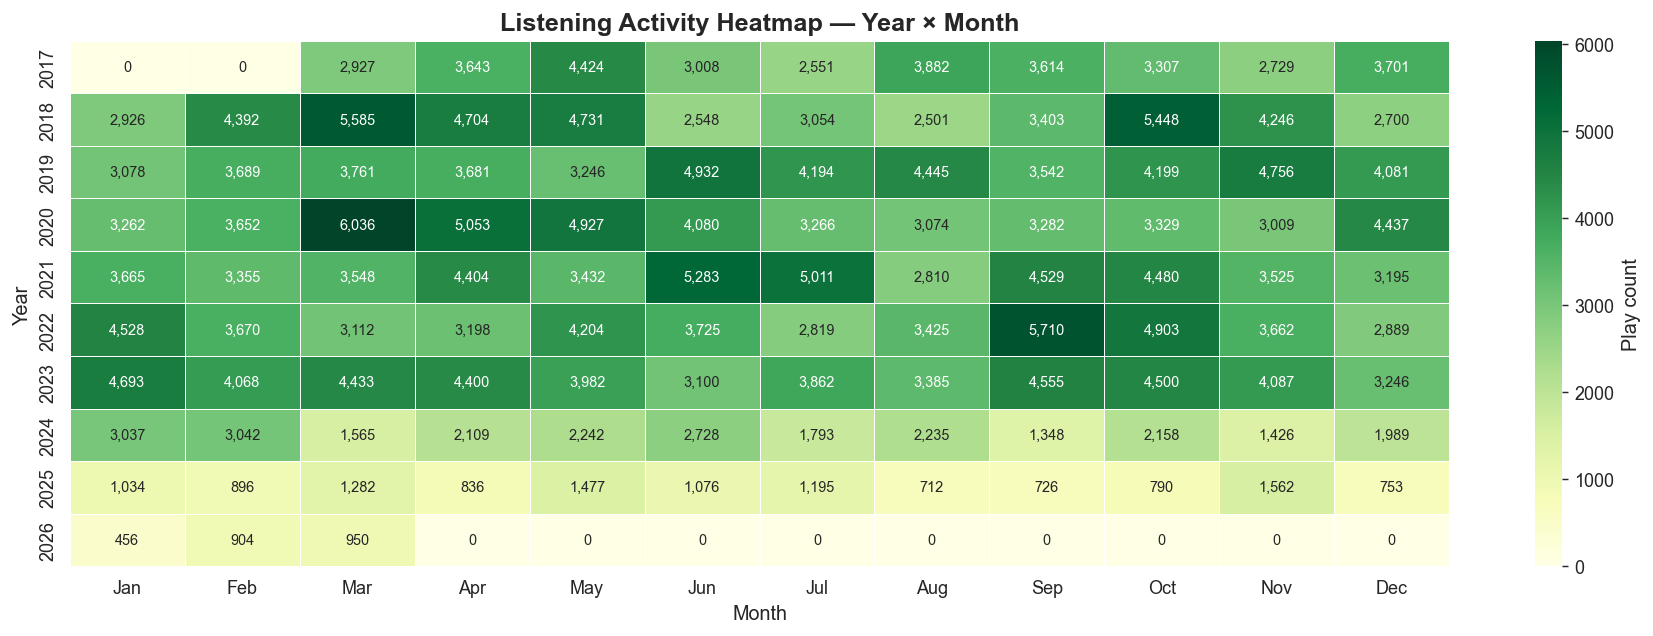

In [22]:
# ── Month-of-year heatmap (year × month) ──────────────────────────────
pivot_hm = (
    clean_df.groupby(['year', 'month']).size()
    .unstack(fill_value=0)
)
pivot_hm.columns = [calendar.month_abbr[m] for m in pivot_hm.columns]

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    pivot_hm, ax=ax,
    cmap='YlGn', linewidths=0.4,
    fmt=',d', annot=True, annot_kws={'size': 8},
    cbar_kws={'label': 'Play count'},
)
ax.set_title('Listening Activity Heatmap — Year × Month')
ax.set_xlabel('Month')
ax.set_ylabel('Year')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_heatmap_year_month.png', bbox_inches='tight')
plt.show()

---
## 6. Top Artists & Tracks <a id='6'></a>

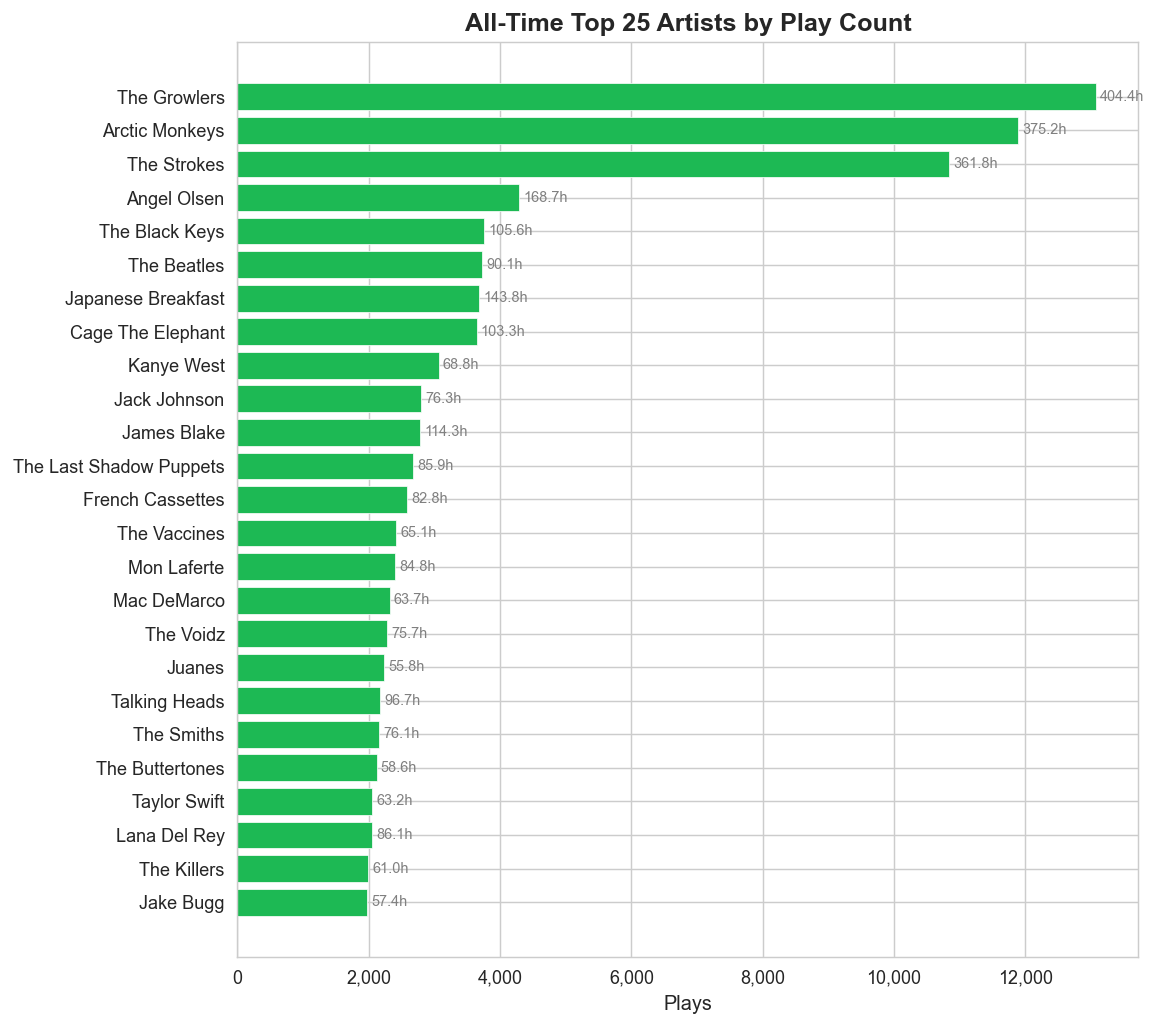

            artist_name  plays    hours
           The Growlers  13069 404.4000
         Arctic Monkeys  11888 375.2000
            The Strokes  10832 361.8000
            Angel Olsen   4290 168.7000
         The Black Keys   3756 105.6000
            The Beatles   3722  90.1000
     Japanese Breakfast   3686 143.8000
      Cage The Elephant   3643 103.3000
             Kanye West   3064  68.8000
           Jack Johnson   2795  76.3000
            James Blake   2782 114.3000
The Last Shadow Puppets   2669  85.9000
       French Cassettes   2584  82.8000
           The Vaccines   2412  65.1000
            Mon Laferte   2399  84.8000
            Mac DeMarco   2317  63.7000
              The Voidz   2277  75.7000
                 Juanes   2231  55.8000
          Talking Heads   2171  96.7000
             The Smiths   2153  76.1000
        The Buttertones   2119  58.6000
           Taylor Swift   2055  63.2000
           Lana Del Rey   2048  86.1000
            The Killers   1994  61.0000


In [23]:
# ── All-time top 25 artists ───────────────────────────────────────────
top_artists = (
    clean_df.groupby('artist_name')
    .agg(plays=('track_id', 'count'),
         hours=('minutes_played', lambda x: round(x.sum() / 60, 1)))
    .sort_values('plays', ascending=False)
    .head(25)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 8))
bars = ax.barh(top_artists['artist_name'][::-1],
               top_artists['plays'][::-1],
               color=SPOTIFY_GREEN, edgecolor='white', linewidth=0.4)
ax.set_title('All-Time Top 25 Artists by Play Count')
ax.set_xlabel('Plays')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
# Annotate with hours
for bar, hrs in zip(bars, top_artists['hours'][::-1]):
    ax.text(bar.get_width() + top_artists['plays'].max() * 0.005,
            bar.get_y() + bar.get_height() / 2,
            f'{hrs}h', va='center', fontsize=8, color='grey')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_top_artists.png', bbox_inches='tight')
plt.show()
print(top_artists[['artist_name','plays','hours']].to_string(index=False))

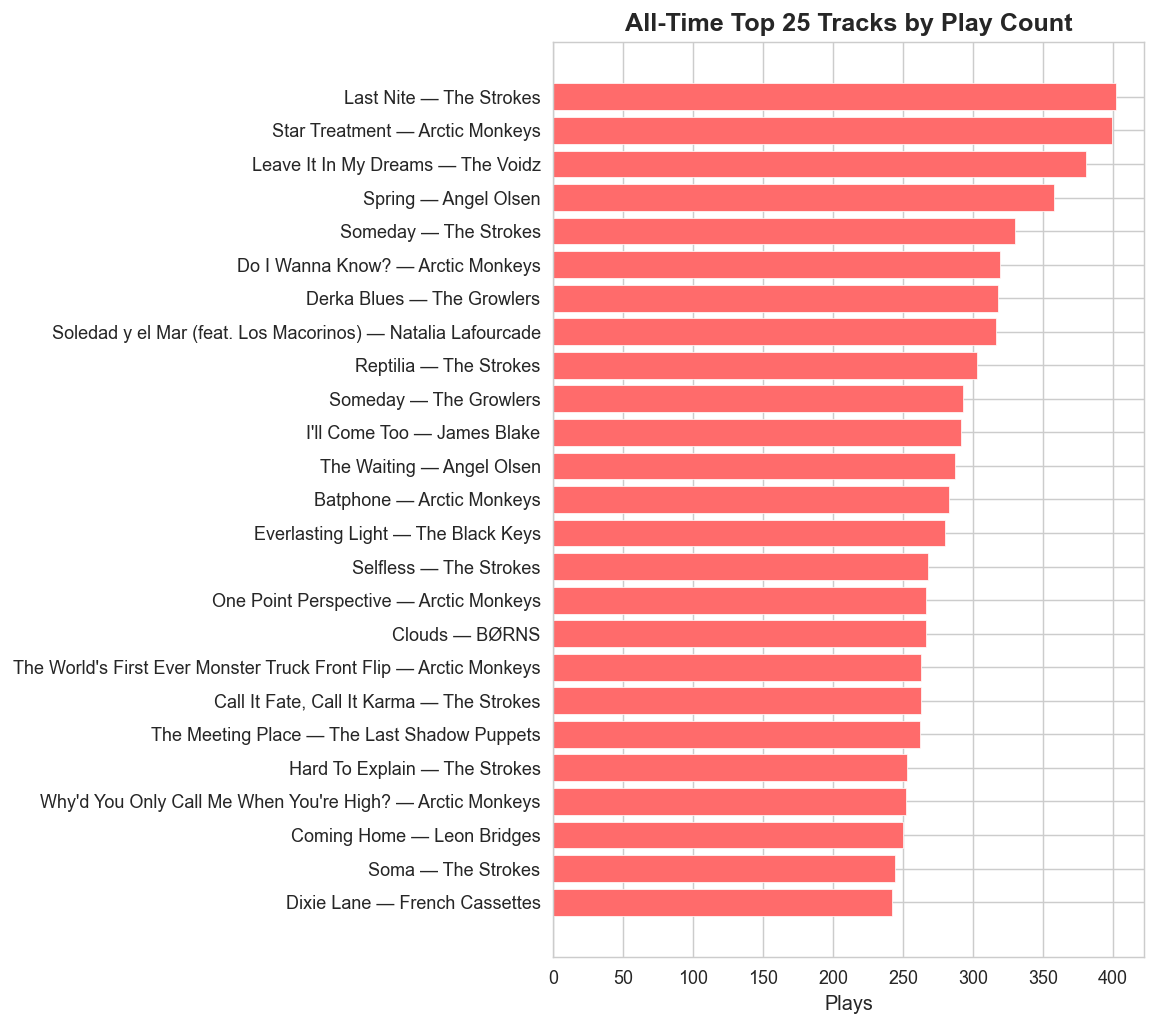

                                     track_name             artist_name  plays
                                      Last Nite             The Strokes    402
                                 Star Treatment          Arctic Monkeys    399
                          Leave It In My Dreams               The Voidz    381
                                         Spring             Angel Olsen    358
                                        Someday             The Strokes    330
                               Do I Wanna Know?          Arctic Monkeys    319
                                    Derka Blues            The Growlers    318
         Soledad y el Mar (feat. Los Macorinos)      Natalia Lafourcade    316
                                       Reptilia             The Strokes    303
                                        Someday            The Growlers    293
                                  I'll Come Too             James Blake    291
                                    The Waiting     

In [24]:
# ── All-time top 25 tracks ────────────────────────────────────────────
top_tracks = (
    clean_df.groupby(['track_id', 'track_name', 'artist_name'])
    .agg(plays=('track_id', 'count'),
         minutes=('minutes_played', 'sum'))
    .sort_values('plays', ascending=False)
    .head(25)
    .reset_index()
)
top_tracks['label'] = top_tracks['track_name'] + ' — ' + top_tracks['artist_name']

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(top_tracks['label'][::-1],
        top_tracks['plays'][::-1],
        color=HIGHLIGHT, edgecolor='white', linewidth=0.4)
ax.set_title('All-Time Top 25 Tracks by Play Count')
ax.set_xlabel('Plays')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_top_tracks.png', bbox_inches='tight')
plt.show()
print(top_tracks[['track_name','artist_name','plays']].to_string(index=False))

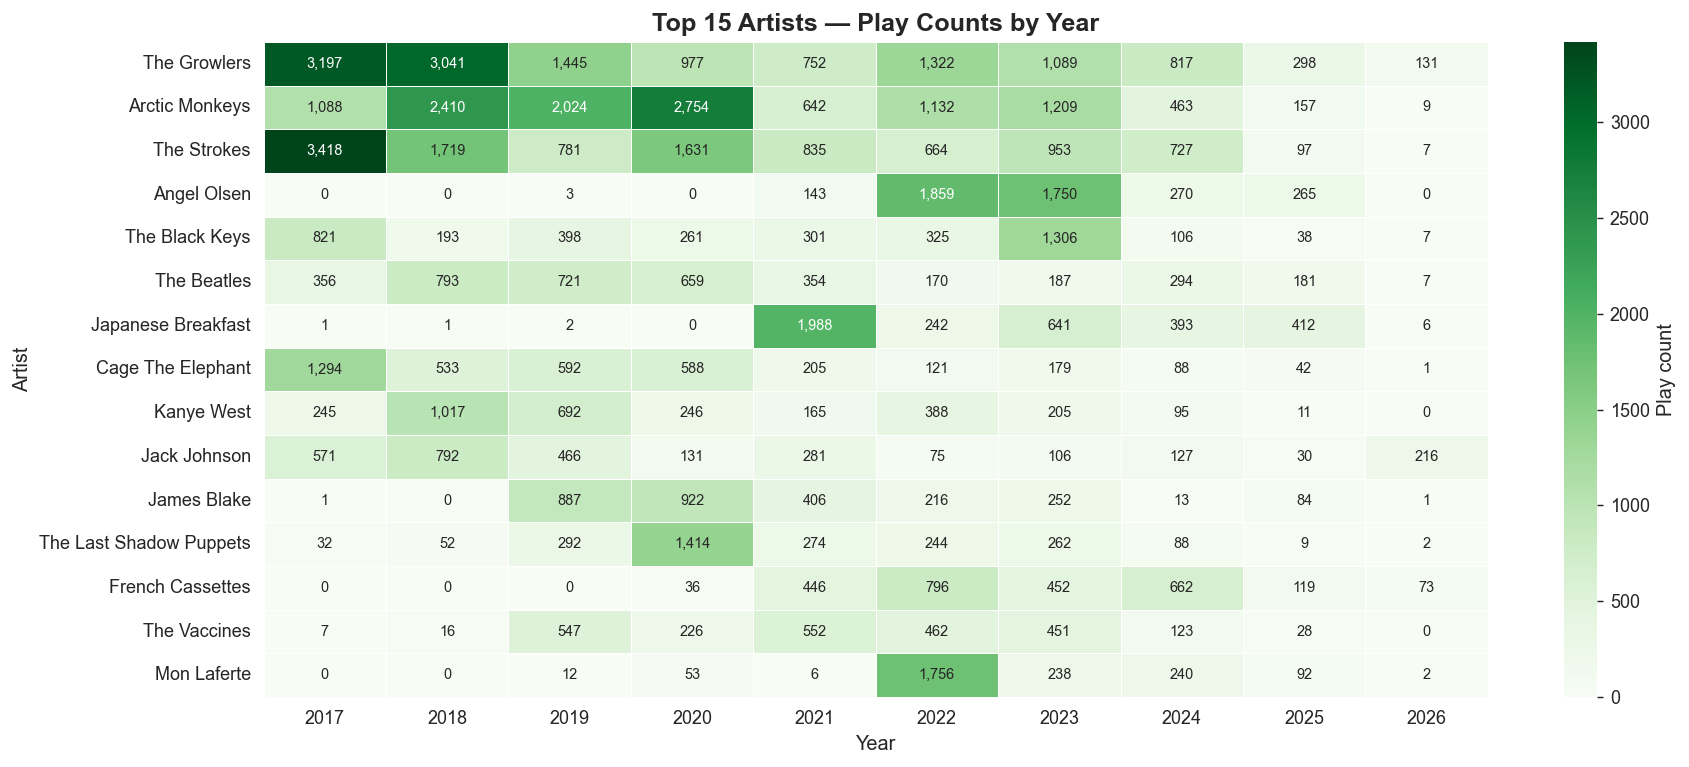

In [38]:
# ── Top 10 artists per year (heatmap) ─────────────────────────────────
yearly_artist = (
    clean_df.groupby(['year', 'artist_name']).size()
    .reset_index(name='plays')
)
# Top 15 artists overall to anchor the heatmap
top15_artists = top_artists['artist_name'].head(15).tolist()
pivot_artists = (
    yearly_artist[yearly_artist['artist_name'].isin(top15_artists)]
    .pivot(index='artist_name', columns='year', values='plays')
    .fillna(0)
    .astype(int)
)
# Sort rows by total plays
pivot_artists = pivot_artists.loc[top15_artists]

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    pivot_artists, ax=ax,
    cmap='Greens', linewidths=0.4,
    fmt=',d', annot=True, annot_kws={'size': 8},
    cbar_kws={'label': 'Play count'},
)
ax.set_title('Top 15 Artists — Play Counts by Year')
ax.set_xlabel('Year')
ax.set_ylabel('Artist')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_top_artists_by_year.png', bbox_inches='tight')
plt.show()

---
## 7. Listening Behaviour <a id='7'></a>

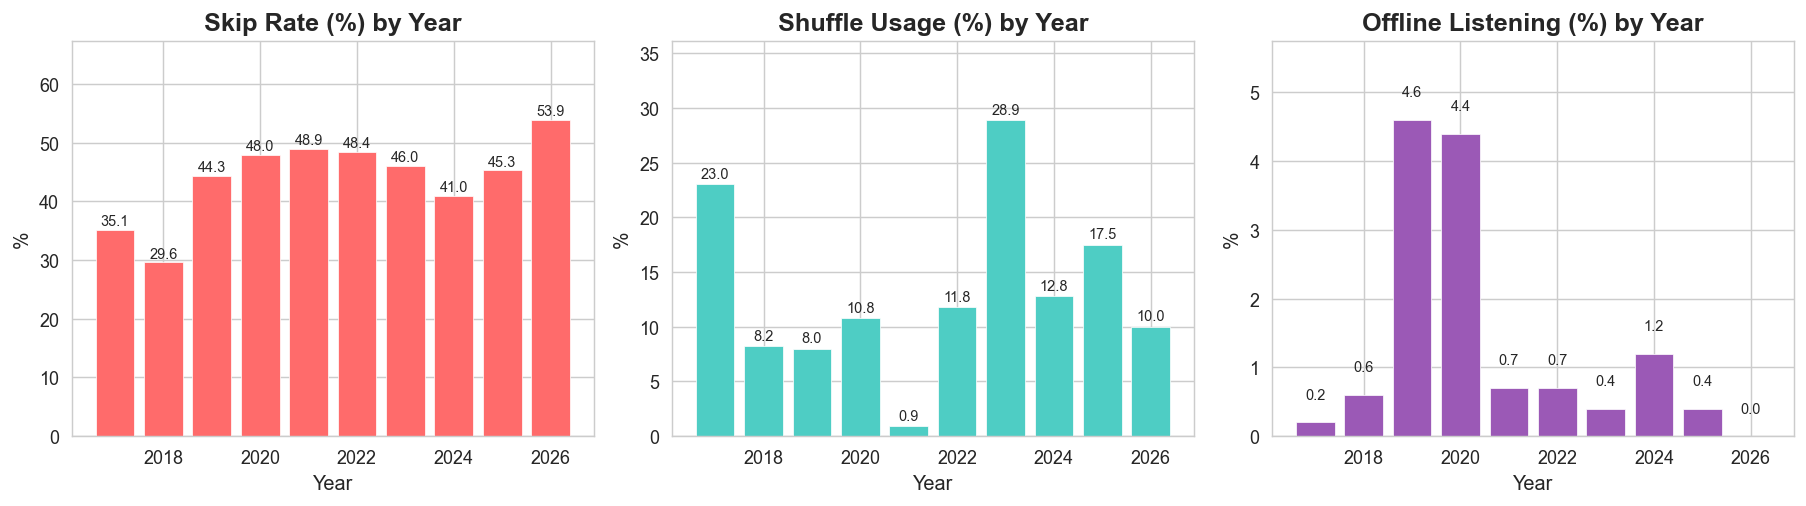

 year  skip_rate  shuffle_pct  offline_pct
 2017    35.1000      23.0000       0.2000
 2018    29.6000       8.2000       0.6000
 2019    44.3000       8.0000       4.6000
 2020    48.0000      10.8000       4.4000
 2021    48.9000       0.9000       0.7000
 2022    48.4000      11.8000       0.7000
 2023    46.0000      28.9000       0.4000
 2024    41.0000      12.8000       1.2000
 2025    45.3000      17.5000       0.4000
 2026    53.9000      10.0000       0.0000


In [39]:
# ── Skip rate & completion metrics ────────────────────────────────────
behaviour = (
    clean_df.groupby('year')
    .agg(
        skip_rate   = ('was_skipped', 'mean'),
        shuffle_pct = ('shuffle',     'mean'),
        offline_pct = ('offline',     'mean'),
    )
    .reset_index()
)
for col in ['skip_rate', 'shuffle_pct', 'offline_pct']:
    behaviour[col] = (behaviour[col] * 100).round(1)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, title, color in zip(
    axes,
    ['skip_rate', 'shuffle_pct', 'offline_pct'],
    ['Skip Rate (%) by Year', 'Shuffle Usage (%) by Year', 'Offline Listening (%) by Year'],
    [HIGHLIGHT, ACCENT3, '#9B59B6'],
):
    ax.bar(behaviour['year'], behaviour[col], color=color, edgecolor='white', linewidth=0.4)
    ax.set_title(title)
    ax.set_xlabel('Year')
    ax.set_ylabel('%')
    ax.set_ylim(0, behaviour[col].max() * 1.25)
    for bar, val in zip(ax.patches, behaviour[col]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                f'{val}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_behaviour.png', bbox_inches='tight')
plt.show()
print(behaviour.to_string(index=False))

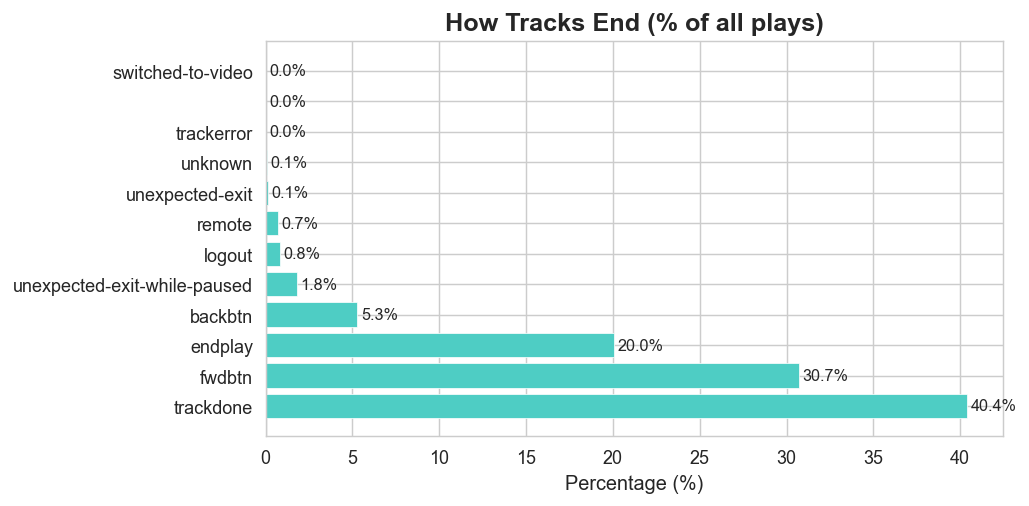

In [40]:
# ── Reason for track ending ───────────────────────────────────────────
reason_end_counts = (
    clean_df['reason_end']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)
reason_end_counts.columns = ['reason_end', 'pct']

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(reason_end_counts['reason_end'],
        reason_end_counts['pct'],
        color=ACCENT3, edgecolor='white', linewidth=0.4)
ax.set_title('How Tracks End (% of all plays)')
ax.set_xlabel('Percentage (%)')
for bar, val in zip(ax.patches, reason_end_counts['pct']):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_reason_end.png', bbox_inches='tight')
plt.show()

---
## 8. Sampling Strategy <a id='8'></a>

To keep output files well under GitHub's size limits, we:

1. Aggregate to **song-level stats per year** (total plays, total minutes, skip rate).
2. From each year, retain the **top `SAMPLE_PER_YEAR` songs** by play count — prioritising tracks that can be matched to SpotifyFeatures for maximum feature coverage.
3. The resulting file is an aggregate summary, not raw play-by-play data.

In [41]:
# ── Song-level aggregates (per year) ──────────────────────────────────
song_year = (
    clean_df.groupby(['year', 'track_id', 'track_name', 'artist_name', 'album_name'])
    .agg(
        plays          = ('ms_played', 'count'),
        total_minutes  = ('minutes_played', 'sum'),
        skip_rate      = ('was_skipped', 'mean'),
        shuffle_rate   = ('shuffle', 'mean'),
    )
    .reset_index()
)
song_year['total_minutes'] = song_year['total_minutes'].round(2)
song_year['skip_rate']     = song_year['skip_rate'].round(4)
song_year['shuffle_rate']  = song_year['shuffle_rate'].round(4)
song_year = song_year.sort_values(['year', 'plays'], ascending=[True, False])

print(f'Total unique (song, year) combinations: {len(song_year):,}')
song_year.head()

Total unique (song, year) combinations: 80,020


,year,track_id,track_name,artist_name,album_name,plays,total_minutes,skip_rate,shuffle_rate
5350,2017,5uplevkaUGRLExATEbSQiR,Someday,The Growlers,Hung At Heart,160,353.0800,0.2625,0.3062
2297,2017,2b9D3N4pnBUbYXVi7vbWy4,Living In A Memory,The Growlers,Hung At Heart,136,356.7300,0.1618,0.5956
95,2017,07SgR5jvYFyVDHa6uv8Fh0,Joy Ride,The Killers,Day & Age,125,197.4400,0.4240,0.2160
518,2017,0ZcZdY4cVfcjZYTUuKgj0E,Wandering eyes,The Growlers,Are You In Or Out?,124,187.2000,0.3468,0.0887
2099,2017,2N4idqj9TT3HnH2OFT9j0v,Still Beating,Mac DeMarco,This Old Dog,123,289.8100,0.1951,0.4797


In [42]:
# ── Load SpotifyFeatures to know which track_ids are available ─────────
sf_path = DATA_DIR / 'SpotifyFeatures.csv'
sf_raw = pd.read_csv(sf_path, encoding='utf-8-sig')
sf_ids = set(sf_raw['track_id'].dropna().unique())
print(f'SpotifyFeatures: {len(sf_raw):,} rows  |  {len(sf_ids):,} unique track_ids')

# Mark which songs in history can be feature-enriched
song_year['has_features'] = song_year['track_id'].isin(sf_ids)
matchable = song_year[song_year['has_features']]
print(f'History songs with SpotifyFeatures match: '
      f'{matchable["track_id"].nunique():,} / {song_year["track_id"].nunique():,} '
      f'({matchable["track_id"].nunique() / song_year["track_id"].nunique() * 100:.1f}%)')

SpotifyFeatures: 232,725 rows  |  176,774 unique track_ids
History songs with SpotifyFeatures match: 12,196 / 47,974 (25.4%)


In [43]:
# ── Sample: top SAMPLE_PER_YEAR per year, features-first ──────────────
def sample_top_per_year(df: pd.DataFrame, n: int) -> pd.DataFrame:
    """
    For each year, take up to n songs:
      - As many feature-matched songs as possible (sorted by plays desc).
      - Fill remaining slots with top non-matched songs.
    """
    frames = []
    for year, grp in df.groupby('year'):
        matched     = grp[grp['has_features']].head(n)
        remaining   = n - len(matched)
        unmatched   = grp[~grp['has_features']].head(remaining) if remaining > 0 else pd.DataFrame()
        frames.append(pd.concat([matched, unmatched]))
    return pd.concat(frames, ignore_index=True)


sampled = sample_top_per_year(song_year, SAMPLE_PER_YEAR)

print(f'Sampled dataset shape: {sampled.shape}')
print(f'Years covered        : {sorted(sampled["year"].unique())}')
print(f'Feature-matched rows : {sampled["has_features"].sum()} '
      f'({sampled["has_features"].mean()*100:.1f}%)')
sampled.head()

Sampled dataset shape: (1000, 10)
Years covered        : [np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025), np.int32(2026)]
Feature-matched rows : 1000 (100.0%)


,year,track_id,track_name,artist_name,album_name,plays,total_minutes,skip_rate,shuffle_rate,has_features
0,2017,5uplevkaUGRLExATEbSQiR,Someday,The Growlers,Hung At Heart,160,353.0800,0.2625,0.3062,True
1,2017,2b9D3N4pnBUbYXVi7vbWy4,Living In A Memory,The Growlers,Hung At Heart,136,356.7300,0.1618,0.5956,True
2,2017,2N4idqj9TT3HnH2OFT9j0v,Still Beating,Mac DeMarco,This Old Dog,123,289.8100,0.1951,0.4797,True
3,2017,6YQeOwMMAkB9MV9yMWmrjh,Threat of Joy,The Strokes,Future Present Past,114,292.3600,0.3070,0.4649,True
4,2017,5n0CTysih20NYdT2S0Wpe8,Trouble,Cage The Elephant,Tell Me I'm Pretty,110,255.5800,0.3636,0.1636,True


In [44]:
# ── Save sampled history ───────────────────────────────────────────────
sampled_path = OUTPUT_DIR / 'sampled_top_songs.csv'
sampled.to_csv(sampled_path, index=False)
size_mb = sampled_path.stat().st_size / 1e6
print(f'Saved: {sampled_path}  ({size_mb:.2f} MB)')

Saved: /Users/adrianrodriguez/Library/CloudStorage/GoogleDrive-jadrian.rod323@gmail.com/My Drive/sonic_universe/data/processed/sampled_top_songs.csv  (0.10 MB)


---
## 9. Feature Enrichment — SpotifyFeatures <a id='9'></a>

We merge the sampled songs with `SpotifyFeatures.csv` on **`track_id`** (extracted from `spotify_track_uri`).

| Field | Source |
|---|---|
| `track_id` | streaming history URI → exact ID |
| Audio features | SpotifyFeatures.csv |

> **Limitation:** SpotifyFeatures is a Kaggle dataset and does not contain every track. Coverage depends on its composition.

In [64]:
# ── Prepare SpotifyFeatures ────────────────────────────────────────────
sf = sf_raw.copy()
# Drop duplicates: keep the row with highest popularity per track_id
sf = (
    sf.sort_values('popularity', ascending=False)
    .drop_duplicates(subset='track_id', keep='first')
    .reset_index(drop=True)
)
# Rename "Children's Music" to "Family Friendly" (Spotify places many
# classic/family-safe tracks in children's playlists, so the label is misleading)
sf['genre'] = sf['genre'].replace("Children's Music", 'Family Friendly')
print(f'SpotifyFeatures after dedup: {len(sf):,} rows')
print('Columns:', sf.columns.tolist())
sf.head(3)

SpotifyFeatures after dedup: 176,774 rows
Columns: ['genre', 'artist_name', 'track_name', 'track_id', 'popularity', 'acousticness', 'danceability', 'duration_ms', 'energy', 'instrumentalness', 'key', 'liveness', 'loudness', 'mode', 'speechiness', 'tempo', 'time_signature', 'valence']


,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Dance,Ariana Grande,7 rings,14msK75pk3pA33pzPVNtBF,100,0.5780,0.7250,178640,0.3210,0.0000,C#,0.0884,-10.7440,Minor,0.3230,70.1420,4/4,0.3190
1,Rap,Post Malone,Wow.,6MWtB6iiXyIwun0YzU6DFP,99,0.1630,0.8330,149520,0.5390,0.0000,B,0.1010,-7.3990,Minor,0.1780,99.9470,4/4,0.3850
2,Pop,Ariana Grande,"break up with your girlfriend, i'm bored",4kV4N9D1iKVxx1KLvtTpjS,99,0.0421,0.7260,190440,0.5540,0.0000,F,0.1060,-5.2900,Minor,0.0917,169.9990,4/4,0.3350


In [65]:
# ── Merge ──────────────────────────────────────────────────────────────
FEATURE_COLS = [
    'track_id', 'genre', 'popularity',
    'acousticness', 'danceability', 'duration_ms', 'energy',
    'instrumentalness', 'key', 'liveness', 'loudness',
    'mode', 'speechiness', 'tempo', 'time_signature', 'valence',
]
sf_slim = sf[[c for c in FEATURE_COLS if c in sf.columns]]

enriched = sampled.merge(sf_slim, on='track_id', how='left')

# Coverage report
total_songs  = enriched['track_id'].nunique()
matched_songs = enriched[enriched['energy'].notna()]['track_id'].nunique()
print(f'Total sampled songs  : {total_songs:,}')
print(f'Songs with features  : {matched_songs:,}  ({matched_songs/total_songs*100:.1f}%)')
print(f'Songs without features: {total_songs - matched_songs:,}')
enriched.head()

Total sampled songs  : 723
Songs with features  : 723  (100.0%)
Songs without features: 0


,year,track_id,track_name,artist_name,album_name,plays,total_minutes,skip_rate,shuffle_rate,has_features,genre,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,2017,5uplevkaUGRLExATEbSQiR,Someday,The Growlers,Hung At Heart,160,353.0800,0.2625,0.3062,True,Indie,48,0.9530,0.4020,215780,0.7720,0.8600,A#,0.1720,-4.5780,Major,0.0394,156.1160,4/4,0.7480
1,2017,2b9D3N4pnBUbYXVi7vbWy4,Living In A Memory,The Growlers,Hung At Heart,136,356.7300,0.1618,0.5956,True,Indie,45,0.1880,0.4160,195530,0.6680,0.6370,D,0.7280,-4.8650,Major,0.0281,85.3570,4/4,0.7930
2,2017,2N4idqj9TT3HnH2OFT9j0v,Still Beating,Mac DeMarco,This Old Dog,123,289.8100,0.1951,0.4797,True,Indie,67,0.5810,0.7090,181587,0.4960,0.1950,C#,0.1510,-10.5280,Minor,0.0417,78.4770,4/4,0.4690
3,2017,6YQeOwMMAkB9MV9yMWmrjh,Threat of Joy,The Strokes,Future Present Past,114,292.3600,0.3070,0.4649,True,Indie,65,0.2160,0.5940,264662,0.7280,0.0881,C,0.1240,-6.9170,Major,0.0281,137.9700,4/4,0.6870
4,2017,5n0CTysih20NYdT2S0Wpe8,Trouble,Cage The Elephant,Tell Me I'm Pretty,110,255.5800,0.3636,0.1636,True,Indie,72,0.3920,0.4700,225973,0.6230,0.0005,C,0.0992,-5.6550,Major,0.0302,77.8610,4/4,0.2980


Feature coverage by year:
 year  feature_coverage_pct
 2017              100.0000
 2018              100.0000
 2019              100.0000
 2020              100.0000
 2021              100.0000
 2022              100.0000
 2023              100.0000
 2024              100.0000
 2025              100.0000
 2026              100.0000


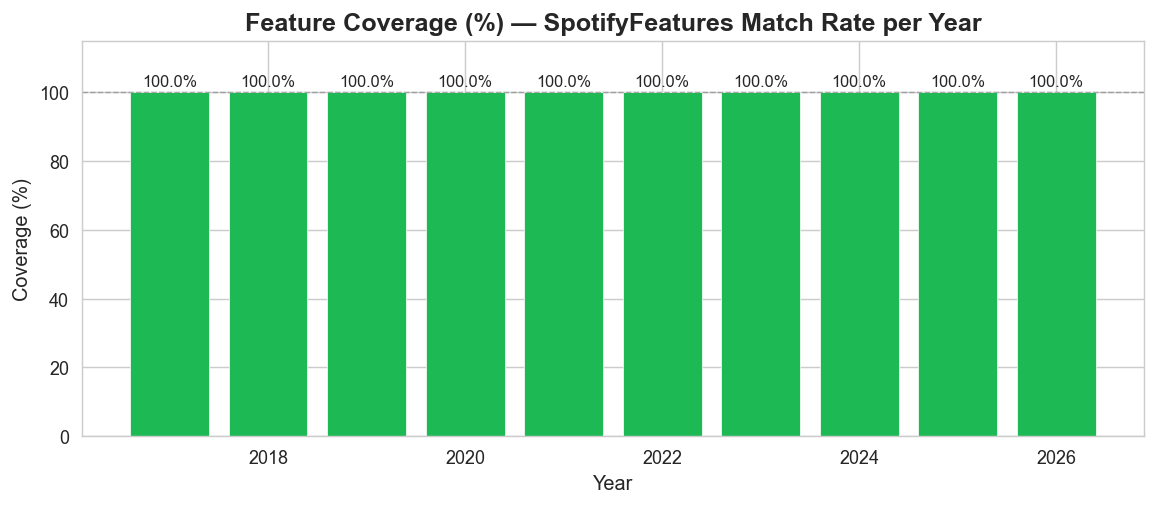

In [66]:
# ── Coverage by year ───────────────────────────────────────────────────
coverage_yr = (
    enriched.groupby('year')
    .apply(lambda g: round(g['energy'].notna().mean() * 100, 1))
    .reset_index(name='feature_coverage_pct')
)
print('Feature coverage by year:')
print(coverage_yr.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(coverage_yr['year'], coverage_yr['feature_coverage_pct'],
       color=SPOTIFY_GREEN, edgecolor='white', linewidth=0.4)
ax.axhline(100, color='grey', linewidth=0.8, linestyle='--', alpha=0.6)
ax.set_title('Feature Coverage (%) — SpotifyFeatures Match Rate per Year')
ax.set_xlabel('Year')
ax.set_ylabel('Coverage (%)')
ax.set_ylim(0, 115)
for bar, val in zip(ax.patches, coverage_yr['feature_coverage_pct']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f'{val}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_feature_coverage.png', bbox_inches='tight')
plt.show()

In [67]:
# ── Save enriched dataset ──────────────────────────────────────────────
enriched_path = OUTPUT_DIR / 'top_songs_with_features.csv'
enriched.to_csv(enriched_path, index=False)
size_mb = enriched_path.stat().st_size / 1e6
print(f'Saved: {enriched_path}  ({size_mb:.2f} MB)')

Saved: /Users/adrianrodriguez/Library/CloudStorage/GoogleDrive-jadrian.rod323@gmail.com/My Drive/sonic_universe/data/processed/top_songs_with_features.csv  (0.19 MB)


---
## 10. Audio Feature Analysis <a id='10'></a>

Analysing the enriched top-songs dataset to understand the sonic profile of favourite tracks.

In [68]:
# Work with feature-enriched rows only
feat_df = enriched[enriched['energy'].notna()].copy()
AUDIO_FEATURES = [
    'acousticness', 'danceability', 'energy',
    'instrumentalness', 'liveness', 'speechiness', 'valence',
]
print(f'Songs with audio features: {len(feat_df):,}')
feat_df[AUDIO_FEATURES].describe().T.round(3)

Songs with audio features: 1,000


,count,mean,std,min,25%,50%,75%,max
acousticness,1000.0000,0.2280,0.2750,0.0000,0.0150,0.0960,0.3490,0.9830
danceability,1000.0000,0.5640,0.1360,0.0800,0.4740,0.5730,0.6530,0.9560
energy,1000.0000,0.6520,0.2050,0.0170,0.5200,0.6770,0.8210,0.9910
instrumentalness,1000.0000,0.1000,0.2320,0.0000,0.0000,0.0000,0.0320,0.9380
liveness,1000.0000,0.1700,0.1210,0.0300,0.0980,0.1210,0.1990,0.9780
speechiness,1000.0000,0.0580,0.0640,0.0230,0.0310,0.0370,0.0550,0.6480
valence,1000.0000,0.5910,0.2270,0.0440,0.4260,0.6140,0.7740,0.9750


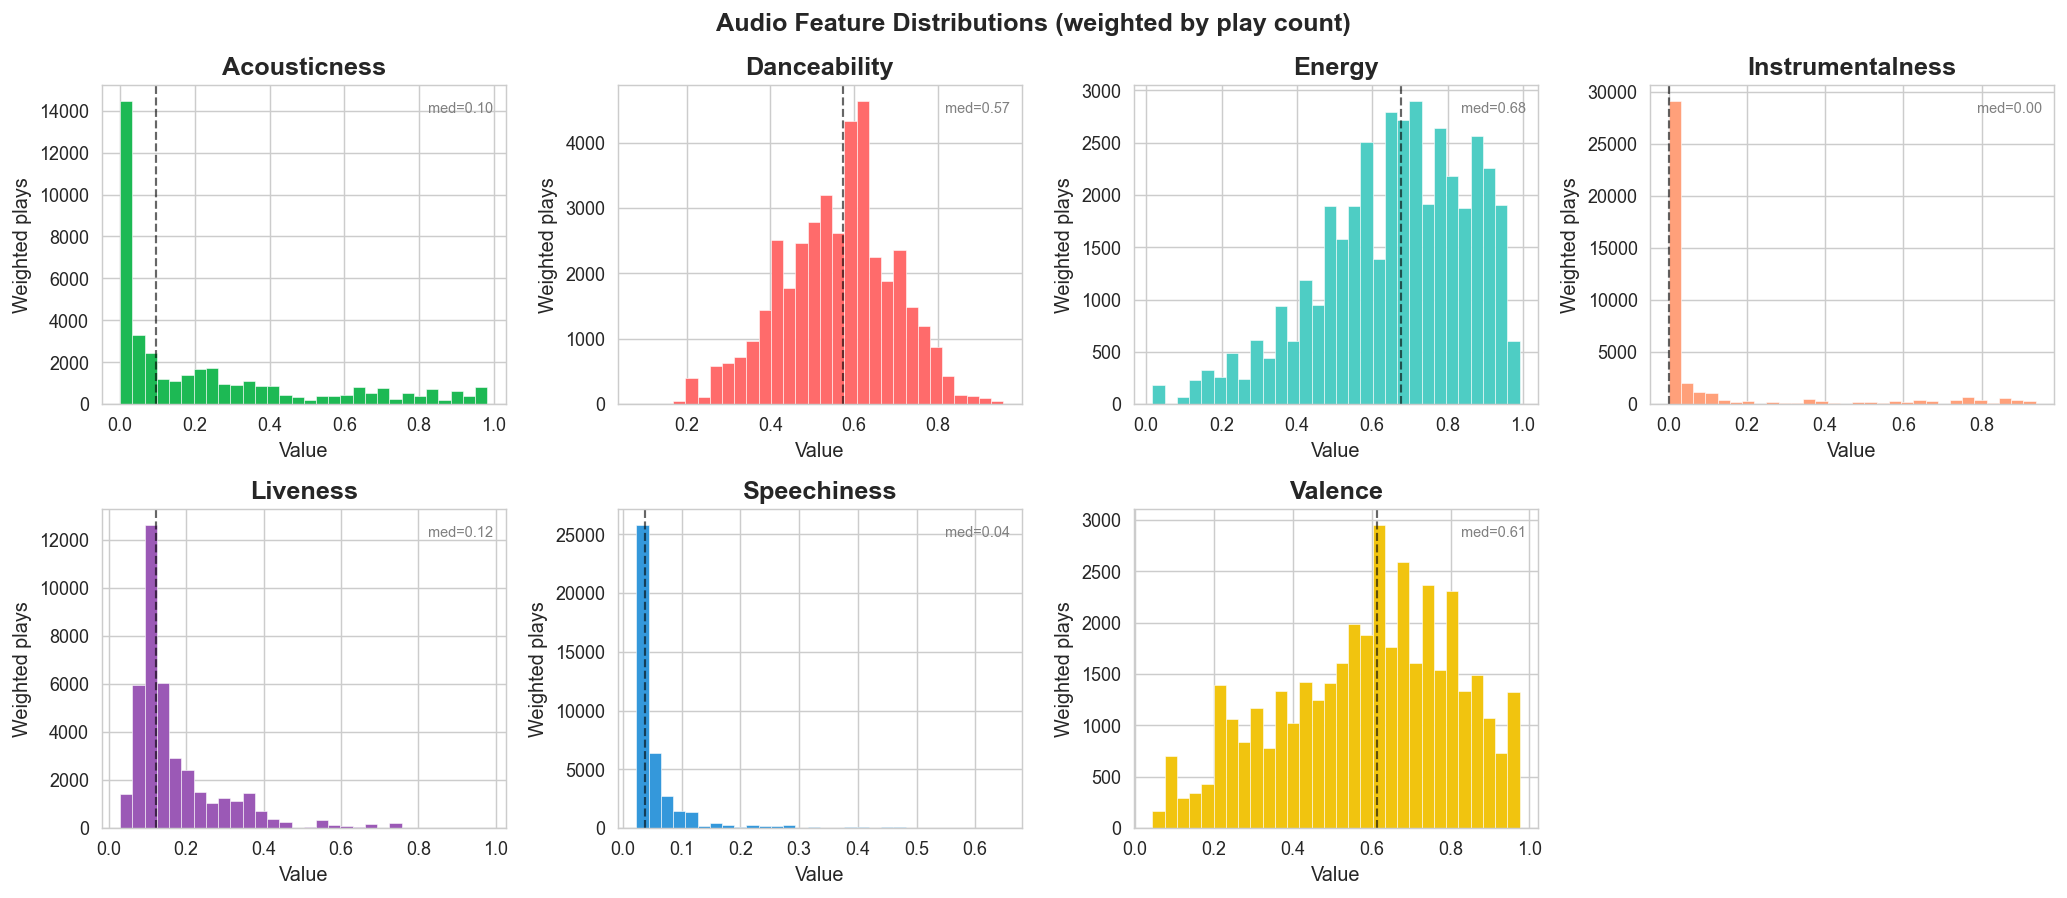

In [69]:
# ── Feature distributions ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, feat in enumerate(AUDIO_FEATURES):
    ax = axes[i]
    # Weighted by play count so top-played songs drive the distribution
    data = feat_df.loc[feat_df[feat].notna(), [feat, 'plays']]
    ax.hist(
        data[feat], bins=30, weights=data['plays'],
        color=PALETTE[i % len(PALETTE)], edgecolor='white', linewidth=0.3,
    )
    med = data[feat].median()
    ax.axvline(med, color='black', linewidth=1.2, linestyle='--', alpha=0.6)
    ax.set_title(feat.capitalize())
    ax.set_xlabel('Value')
    ax.set_ylabel('Weighted plays')
    ax.text(0.97, 0.95, f'med={med:.2f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=8, color='grey')

axes[-1].set_visible(False)
fig.suptitle('Audio Feature Distributions (weighted by play count)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_feature_distributions.png', bbox_inches='tight')
plt.show()

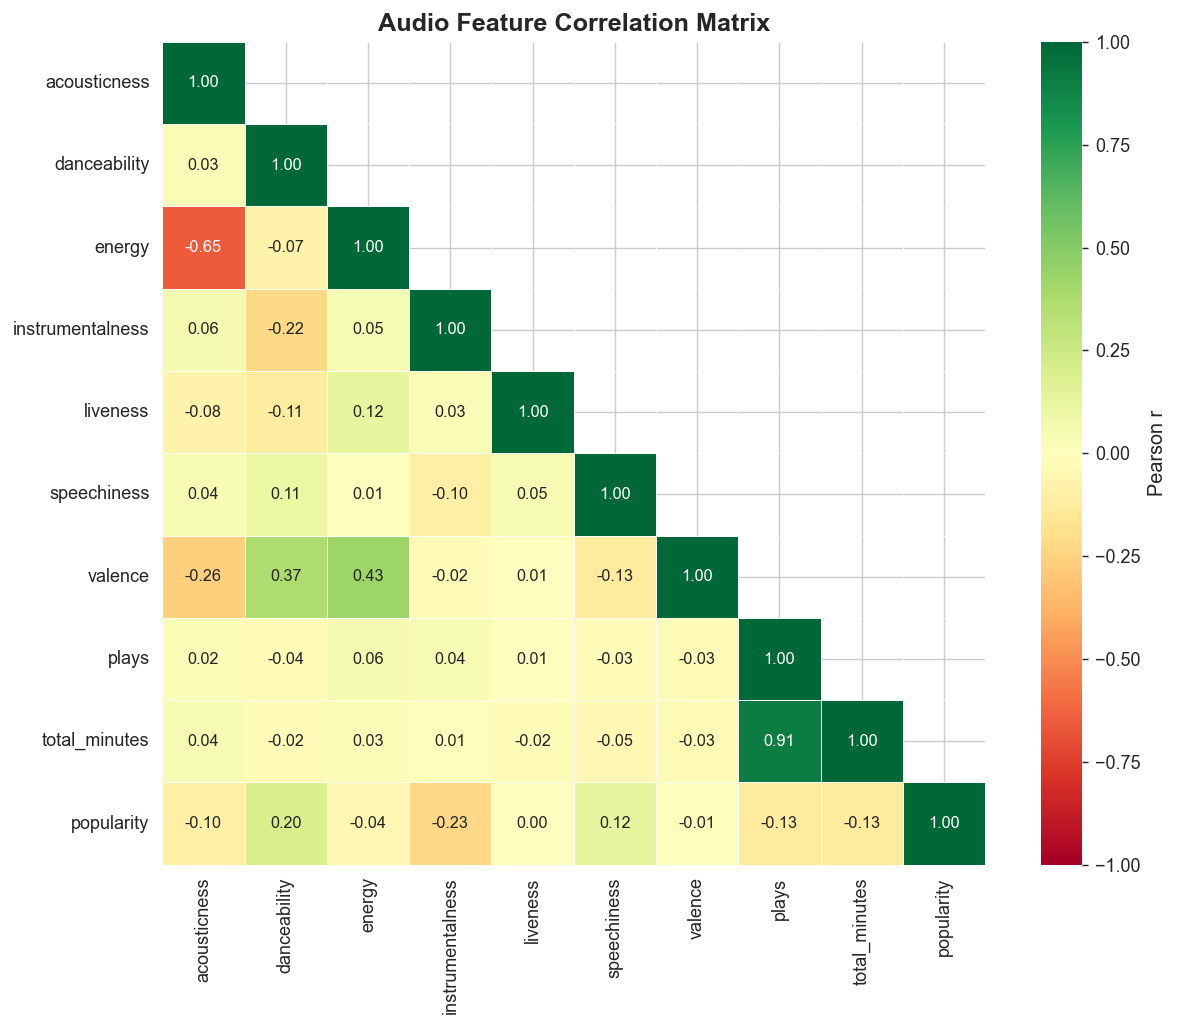

In [70]:
# ── Correlation matrix ────────────────────────────────────────────────
corr = feat_df[AUDIO_FEATURES + ['plays', 'total_minutes', 'popularity']].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr, ax=ax, mask=mask,
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f', annot_kws={'size': 9},
    linewidths=0.5, square=True,
    cbar_kws={'label': 'Pearson r'},
)
ax.set_title('Audio Feature Correlation Matrix')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_correlation_matrix.png', bbox_inches='tight')
plt.show()

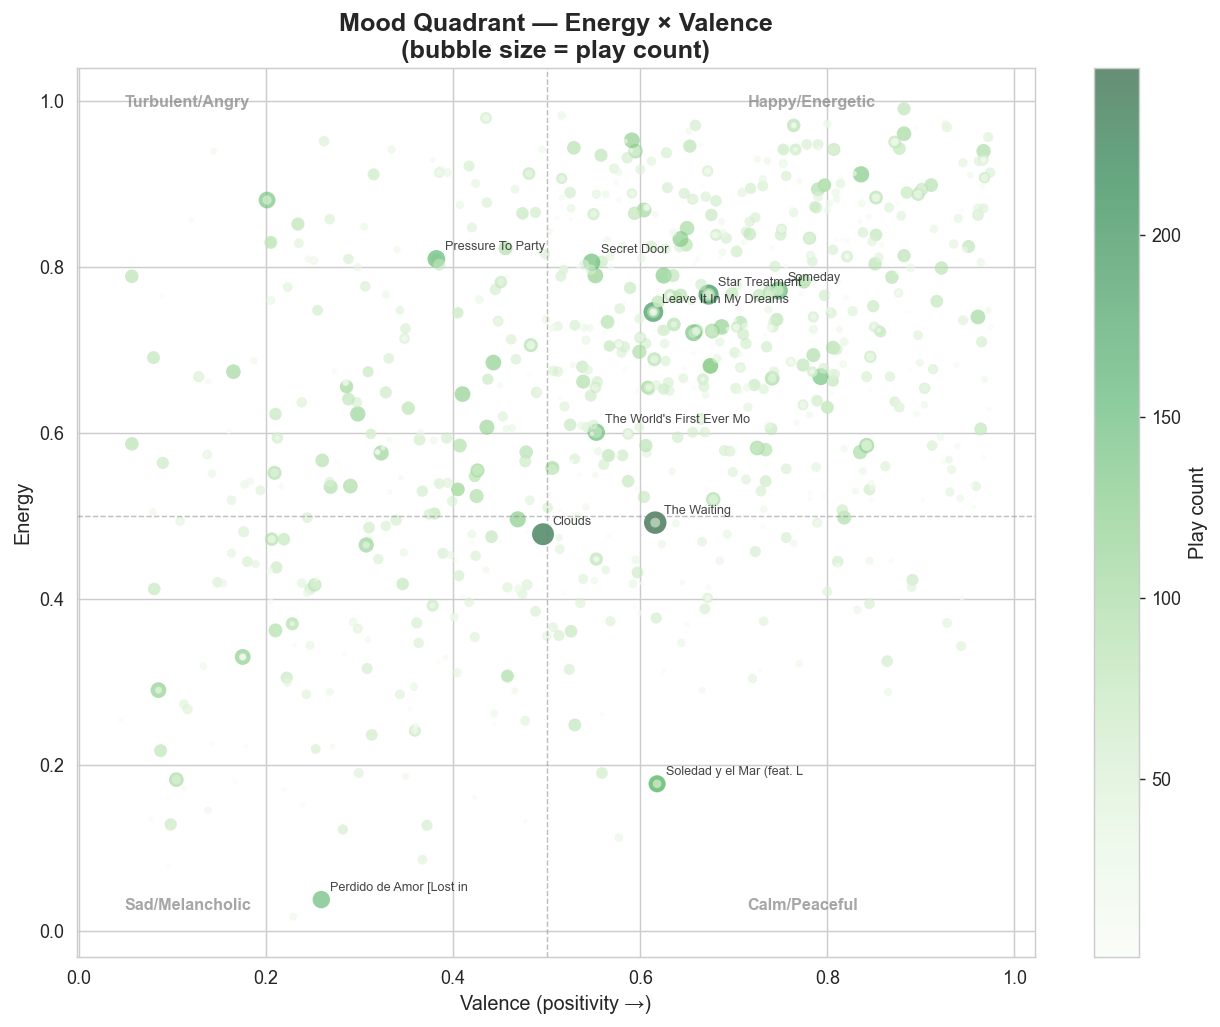

In [71]:
# ── Mood quadrant: Energy × Valence ───────────────────────────────────
# Quadrants: Happy/Energetic | Angry/Tense | Calm/Peaceful | Sad/Melancholic
top50 = feat_df.nlargest(50, 'plays')

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(
    feat_df['valence'], feat_df['energy'],
    c=feat_df['plays'], cmap='Greens',
    s=feat_df['plays'] / feat_df['plays'].max() * 150 + 5,
    alpha=0.6, edgecolors='none',
)
# Label top 10 most-played
for _, row in top50.head(10).iterrows():
    ax.annotate(
        row['track_name'][:25],
        (row['valence'], row['energy']),
        fontsize=7, alpha=0.85,
        xytext=(5, 5), textcoords='offset points',
    )

# Quadrant lines
ax.axvline(0.5, color='grey', linewidth=0.8, linestyle='--', alpha=0.5)
ax.axhline(0.5, color='grey', linewidth=0.8, linestyle='--', alpha=0.5)

# Quadrant labels
quad_kw = dict(fontsize=9, color='grey', alpha=0.7, fontweight='bold')
ax.text(0.05, 0.97, 'Turbulent/Angry',    transform=ax.transAxes, va='top', **quad_kw)
ax.text(0.70, 0.97, 'Happy/Energetic',    transform=ax.transAxes, va='top', **quad_kw)
ax.text(0.05, 0.05, 'Sad/Melancholic',    transform=ax.transAxes, va='bottom', **quad_kw)
ax.text(0.70, 0.05, 'Calm/Peaceful',      transform=ax.transAxes, va='bottom', **quad_kw)

plt.colorbar(scatter, ax=ax, label='Play count')
ax.set_xlabel('Valence (positivity →)')
ax.set_ylabel('Energy')
ax.set_title('Mood Quadrant — Energy × Valence\n(bubble size = play count)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig_mood_quadrant.png', bbox_inches='tight')
plt.show()

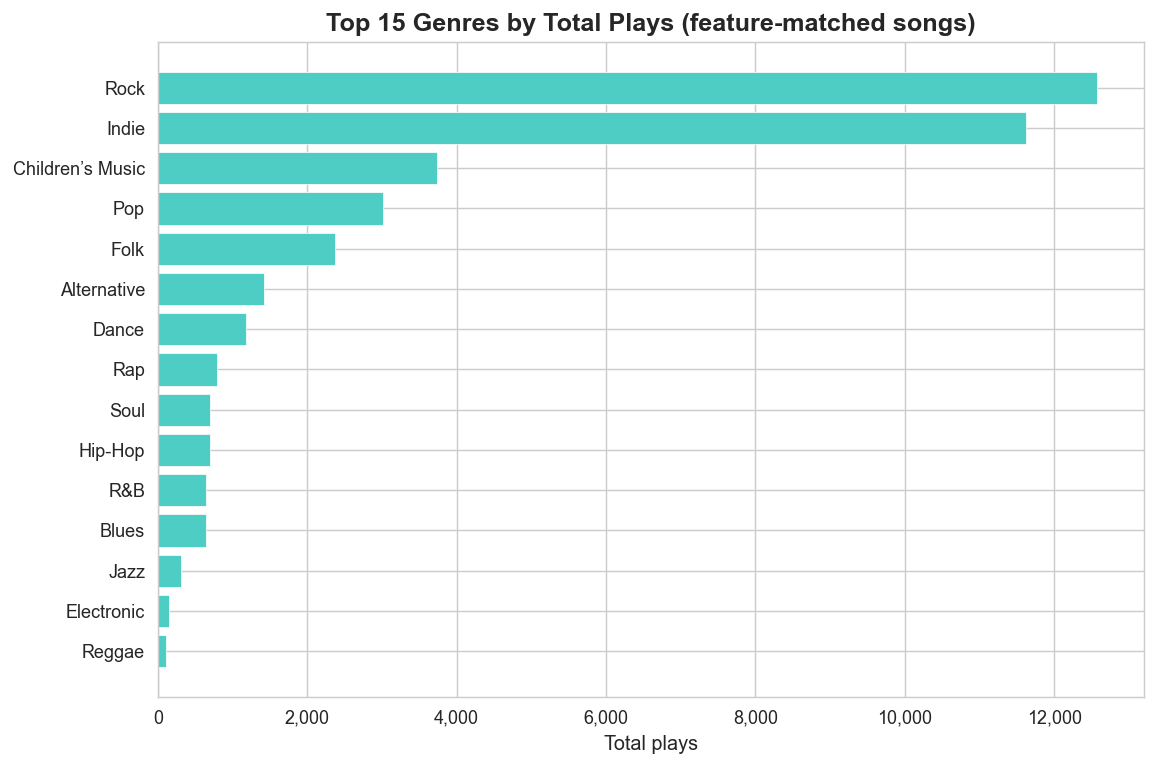

In [72]:
# ── Genre breakdown ───────────────────────────────────────────────────
if 'genre' in feat_df.columns:
    genre_plays = (
        feat_df.groupby('genre')['plays']
        .sum()
        .sort_values(ascending=False)
        .head(15)
        .reset_index()
    )
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(genre_plays['genre'][::-1],
            genre_plays['plays'][::-1],
            color=ACCENT3, edgecolor='white', linewidth=0.4)
    ax.set_title('Top 15 Genres by Total Plays (feature-matched songs)')
    ax.set_xlabel('Total plays')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'fig_genre_breakdown.png', bbox_inches='tight')
    plt.show()

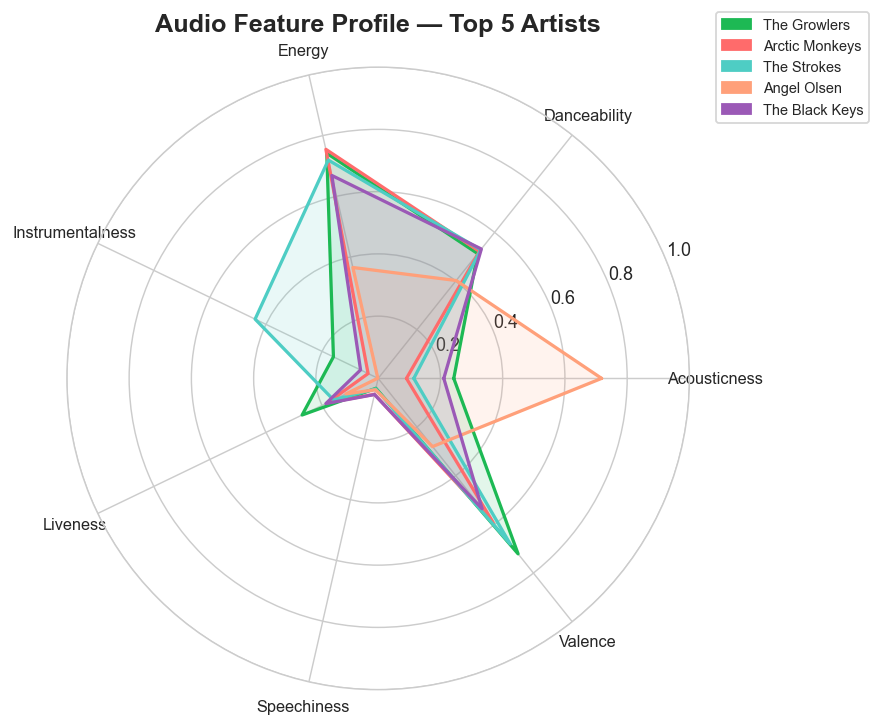

In [73]:
# ── Radar chart: average feature profile for top 5 artists ────────────
import matplotlib.patches as mpatches

top5_artists = top_artists['artist_name'].head(5).tolist()
feat_top5 = feat_df[feat_df['artist_name'].isin(top5_artists)]

radar_features = ['acousticness','danceability','energy',
                  'instrumentalness','liveness','speechiness','valence']

artist_profiles = (
    feat_top5.groupby('artist_name')[radar_features]
    .mean()
    .loc[[a for a in top5_artists if a in feat_top5['artist_name'].values]]
)

if len(artist_profiles) > 0:
    N = len(radar_features)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]  # close the polygon

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
    colors  = PALETTE[:len(artist_profiles)]
    patches = []

    for (artist, row), color in zip(artist_profiles.iterrows(), colors):
        values = row.tolist() + row.tolist()[:1]
        ax.plot(angles, values, linewidth=1.8, color=color)
        ax.fill(angles, values, alpha=0.12, color=color)
        patches.append(mpatches.Patch(color=color, label=artist))

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([f.capitalize() for f in radar_features], fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_title('Audio Feature Profile — Top 5 Artists', pad=20, fontweight='bold')
    ax.legend(handles=patches, loc='upper right',
              bbox_to_anchor=(1.3, 1.1), fontsize=8)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'fig_artist_radar.png', bbox_inches='tight')
    plt.show()
else:
    print('Top artists not found in SpotifyFeatures — skipping radar chart.')

---
## 11. Final Output: Top Songs with Features <a id='11'></a>

A consolidated view of your most-played songs and their audio DNA.

In [74]:
# ── All-time top songs with features ─────────────────────────────────
all_time = (
    enriched
    .groupby(['track_id', 'track_name', 'artist_name', 'album_name',
              'genre', 'popularity',
              'acousticness', 'danceability', 'energy',
              'instrumentalness', 'liveness', 'speechiness', 'valence',
              'tempo', 'key', 'mode', 'loudness', 'time_signature'])
    .agg(
        total_plays   = ('plays', 'sum'),
        total_minutes = ('total_minutes', 'sum'),
        avg_skip_rate = ('skip_rate', 'mean'),
        years_active  = ('year', lambda x: sorted(x.unique().tolist())),
    )
    .reset_index()
    .sort_values('total_plays', ascending=False)
    .reset_index(drop=True)
)
all_time['total_minutes'] = all_time['total_minutes'].round(1)
all_time['avg_skip_rate'] = all_time['avg_skip_rate'].round(3)

print(f'Final enriched table: {len(all_time):,} unique songs')
print(f'With audio features : {all_time["energy"].notna().sum():,}')

display_cols = [
    'track_name', 'artist_name', 'total_plays', 'total_minutes',
    'genre', 'popularity', 'energy', 'danceability', 'valence',
    'acousticness', 'tempo', 'avg_skip_rate'
]
all_time[[c for c in display_cols if c in all_time.columns]].head(20)

Final enriched table: 724 unique songs
With audio features : 724


,track_name,artist_name,total_plays,total_minutes,genre,popularity,energy,danceability,valence,acousticness,tempo,avg_skip_rate
0,Last Nite,The Strokes,374,680.4000,Rock,70,0.8990,0.6240,0.7970,0.0223,104.0550,0.4220
1,Star Treatment,Arctic Monkeys,372,1423.9000,Rock,63,0.7670,0.5810,0.6730,0.2430,120.0700,0.3680
2,Leave It In My Dreams,The Voidz,316,900.6000,Alternative,53,0.7460,0.6000,0.6140,0.0226,118.5510,0.3840
3,Soledad y el Mar (feat. Los Macorinos),Natalia Lafourcade,300,628.1000,Rock,60,0.1770,0.7260,0.6180,0.8960,92.9340,0.3820
4,Someday,The Growlers,293,619.4000,Indie,48,0.7720,0.4020,0.7480,0.9530,156.1160,0.3430
5,The Waiting,Angel Olsen,287,855.2000,Folk,42,0.4920,0.6060,0.6160,0.7200,108.2890,0.2010
6,One Point Perspective,Arctic Monkeys,250,562.2000,Indie,62,0.5850,0.7140,0.8420,0.0570,77.1040,0.3520
7,Someday,The Strokes,249,363.7000,Children’s Music,68,0.5200,0.5380,0.6780,0.0043,106.0310,0.5040
8,Do I Wanna Know?,Arctic Monkeys,238,535.1000,Rock,84,0.5320,0.5480,0.4050,0.1860,85.0300,0.3690
9,Clouds,BØRNS,234,628.2000,Pop,58,0.4780,0.6440,0.4960,0.1940,159.8980,0.1320


In [75]:
# ── Save all-time top songs ────────────────────────────────────────────
alltime_path = OUTPUT_DIR / 'alltime_top_songs_with_features.csv'
all_time.to_csv(alltime_path, index=False)
size_mb = alltime_path.stat().st_size / 1e6
print(f'Saved: {alltime_path}  ({size_mb:.3f} MB)')

print('\n--- OUTPUT SUMMARY ---')
print(f'  sampled_top_songs.csv                 — sampled top {SAMPLE_PER_YEAR} songs per year')
print(f'  top_songs_with_features.csv           — sampled songs with audio features')
print(f'  alltime_top_songs_with_features.csv   — all-time ranking with features')
print(f'  fig_*.png                             — all exported visualisations')

Saved: /Users/adrianrodriguez/Library/CloudStorage/GoogleDrive-jadrian.rod323@gmail.com/My Drive/sonic_universe/data/processed/alltime_top_songs_with_features.csv  (0.127 MB)

--- OUTPUT SUMMARY ---
  sampled_top_songs.csv                 — sampled top 100 songs per year
  top_songs_with_features.csv           — sampled songs with audio features
  alltime_top_songs_with_features.csv   — all-time ranking with features
  fig_*.png                             — all exported visualisations


In [76]:
# ── Quick stat card ────────────────────────────────────────────────────
with_feats = all_time[all_time['energy'].notna()]

print('=' * 55)
print('  YOUR SONIC UNIVERSE — STATS CARD')
print('=' * 55)
print(f'  Total play events           : {total_plays:,}')
print(f'  Total hours listened        : {clean_df["minutes_played"].sum()/60:,.0f} h')
print(f'  Unique tracks heard         : {clean_df["track_id"].nunique():,}')
print(f'  Unique artists heard        : {clean_df["artist_name"].nunique():,}')
print(f'  #1 track (all time)         : {all_time.iloc[0]["track_name"]}  '
      f'by {all_time.iloc[0]["artist_name"]}  '
      f'({all_time.iloc[0]["total_plays"]:,} plays)')
print(f'  #1 artist (all time)        : {top_artists.iloc[0]["artist_name"]}  '
      f'({top_artists.iloc[0]["plays"]:,} plays)')
if len(with_feats):
    wf_w = with_feats.set_index('track_name')  # for weighted stats
    avg_e = (with_feats['energy']     * with_feats['total_plays']).sum() / with_feats['total_plays'].sum()
    avg_d = (with_feats['danceability']* with_feats['total_plays']).sum() / with_feats['total_plays'].sum()
    avg_v = (with_feats['valence']    * with_feats['total_plays']).sum() / with_feats['total_plays'].sum()
    print(f'  Avg energy (weighted)       : {avg_e:.2f}')
    print(f'  Avg danceability (weighted) : {avg_d:.2f}')
    print(f'  Avg valence (weighted)      : {avg_v:.2f}')
print('=' * 55)

  YOUR SONIC UNIVERSE — STATS CARD
  Total play events           : 356,749
  Total hours listened        : 10,524 h
  Unique tracks heard         : 47,974
  Unique artists heard        : 11,907
  #1 track (all time)         : Last Nite  by The Strokes  (374 plays)
  #1 artist (all time)        : The Growlers  (13,069 plays)
  Avg energy (weighted)       : 0.66
  Avg danceability (weighted) : 0.56
  Avg valence (weighted)      : 0.58
